In [ ]:
from model import *
import numpy as np
import random
from sklearn.metrics import ConfusionMatrixDisplay, precision_score, recall_score, f1_score, adjusted_rand_score
from scipy.optimize import linear_sum_assignment
import pandas as pd
from model.initialization import init_blocks_spectral, init_spectral_with_z
from helper_functions.Generate_mixture_data import * 

from helper_functions.Estimate_p import estimate_p_multicluster, match_clusters

## Find MAP

## Generate data


Old version

In [2]:
# def generate_mixture_data(
#     n_assessors=100,
#     n_items=10,
#     C=3,
#     seed=1,
#     gap=1.2,
#     sigma=0.8,
#     tau=None,
#     n_blocks=None,
#     n_blocks_range=(3, 6),
#     min_block_size=1,
# ):
#     rng = np.random.default_rng(seed)

#     if n_items < 1:
#         raise ValueError("n_items must be >= 1")
#     if C < 1:
#         raise ValueError("C must be >= 1")
#     if min_block_size < 1:
#         raise ValueError("min_block_size must be >= 1")

#     # ---- tau ----
#     if tau is None:
#         tau = np.ones(C) / C
#     else:
#         tau = np.asarray(tau, dtype=float)
#         if tau.shape != (C,):
#             raise ValueError(f"tau must have length C={C}")
#         if tau.sum() <= 0:
#             raise ValueError("tau must sum to a positive value")
#         tau = tau / tau.sum()

#     def choose_k():
#         if n_blocks is not None:
#             k = int(n_blocks)
#         else:
#             lo, hi = n_blocks_range
#             if lo < 1 or hi < lo:
#                 raise ValueError("n_blocks_range must be (low>=1, high>=low)")
#             k = int(rng.integers(lo, hi + 1))

#         # cap so we can give each block at least min_block_size items
#         k_max = n_items // min_block_size
#         if k_max < 1:
#             # min_block_size > n_items, so only possible is 1 block
#             return 1
#         return max(1, min(k, k_max))

#     def sizes_no_empty(total, k, min_part):
#         """
#         Return k sizes summing to total, each >= min_part.
#         This cannot produce zeros.
#         """
#         base = np.full(k, min_part, dtype=int)
#         remaining = total - k * min_part
#         if remaining < 0:
#             raise ValueError(f"Impossible: total={total}, k={k}, min_part={min_part}")

#         # distribute remaining across k blocks (some blocks may get +0, but base ensures >= min_part)
#         extras = rng.multinomial(remaining, np.ones(k) / k)
#         sizes = base + extras

#         # Optional: randomize the order of sizes so earlier blocks aren't biased
#         rng.shuffle(sizes)
#         return sizes.tolist()

#     def make_cluster_blocks():
#         k = choose_k()
#         sizes = sizes_no_empty(n_items, k, min_block_size)

#         items = rng.permutation(n_items).tolist()
#         blocks = []
#         idx = 0
#         for sz in sizes:
#             block = items[idx: idx + sz]
#             # This should *never* happen now, but keep as a hard check
#             if len(block) == 0:
#                 raise RuntimeError("Empty block generated — this should be impossible.")
#             blocks.append(block)
#             idx += sz

#         # sanity checks
#         if idx != n_items:
#             raise RuntimeError("Internal error: did not consume exactly n_items.")
#         if len(set(x for b in blocks for x in b)) != n_items:
#             raise RuntimeError("Internal error: items repeated or missing.")
#         return blocks

#     true_blocks = [make_cluster_blocks() for _ in range(C)]

#     z_true = rng.choice(C, size=n_assessors, p=tau)

#     def ranking_from_blocks(blocks):
#         base = np.zeros(n_items)
#         for level, block in enumerate(blocks):
#             for item in block:
#                 base[item] = -gap * level
#         scores = base + rng.normal(0.0, sigma, size=n_items)
#         return list(np.argsort(-scores))

#     rankings = [ranking_from_blocks(true_blocks[z]) for z in z_true]

#     return true_blocks, tau.tolist(), z_true.tolist(), rankings

# Map prediciton to true labels

In [3]:
# match_clusters is now imported from helper_functions.Estimate_p
# It aligns predicted cluster labels with true labels using the Hungarian algorithm

## Run MCMC

In [4]:
# # Old method of generating data 
# C_true = 3
# C = 6
# n_items = 15
# n_blocks_range=(5, 8)
# n_assessors = 100

# gamma = 1
# delta = 0.5

# true_blocks, true_tau, z_true, rankings = generate_mixture_data(
# n_assessors=n_assessors,
# seed=123,
# gap=2,
# sigma=0.5,
# C = C_true,
# n_items=n_items,
# n_blocks_range=n_blocks_range
# )

In [ ]:
# New method of generating data 
C_true = 10
C = 20
n_items = 150
n_blocks_range=(50, 70)
n_assessors = 200

gamma = 1
delta = 0.5
theta = 0.1 # Controlls noise. Lower values equals more noise, higher values equals less noise 

true_blocks, true_tau, z_true, rankings = generate_mixture_data(
    n_assessors=n_assessors,
    seed=123,
    theta=theta,
    C = C_true,
    n_items=n_items,
    n_blocks_range=n_blocks_range
    )

In [ ]:
# Initate with spectral clustering
clusters, z_init = init_spectral_with_z(
    rankings=rankings,
    n_clusters=C,
    py_sampling=False,  # Use simpler ~n/2 blocks
    gamma=gamma,
    delta=delta,
    seed=123
    )

Clustering accuracy: 0.6850  |  C_true=10, C_init=20
Label mapping (pred -> true): {np.int64(9): np.int64(0), np.int64(14): np.int64(1), np.int64(8): np.int64(2), np.int64(1): np.int64(3), np.int64(5): np.int64(4), np.int64(12): np.int64(5), np.int64(6): np.int64(6), np.int64(3): np.int64(7), np.int64(4): np.int64(8), np.int64(11): np.int64(9)}


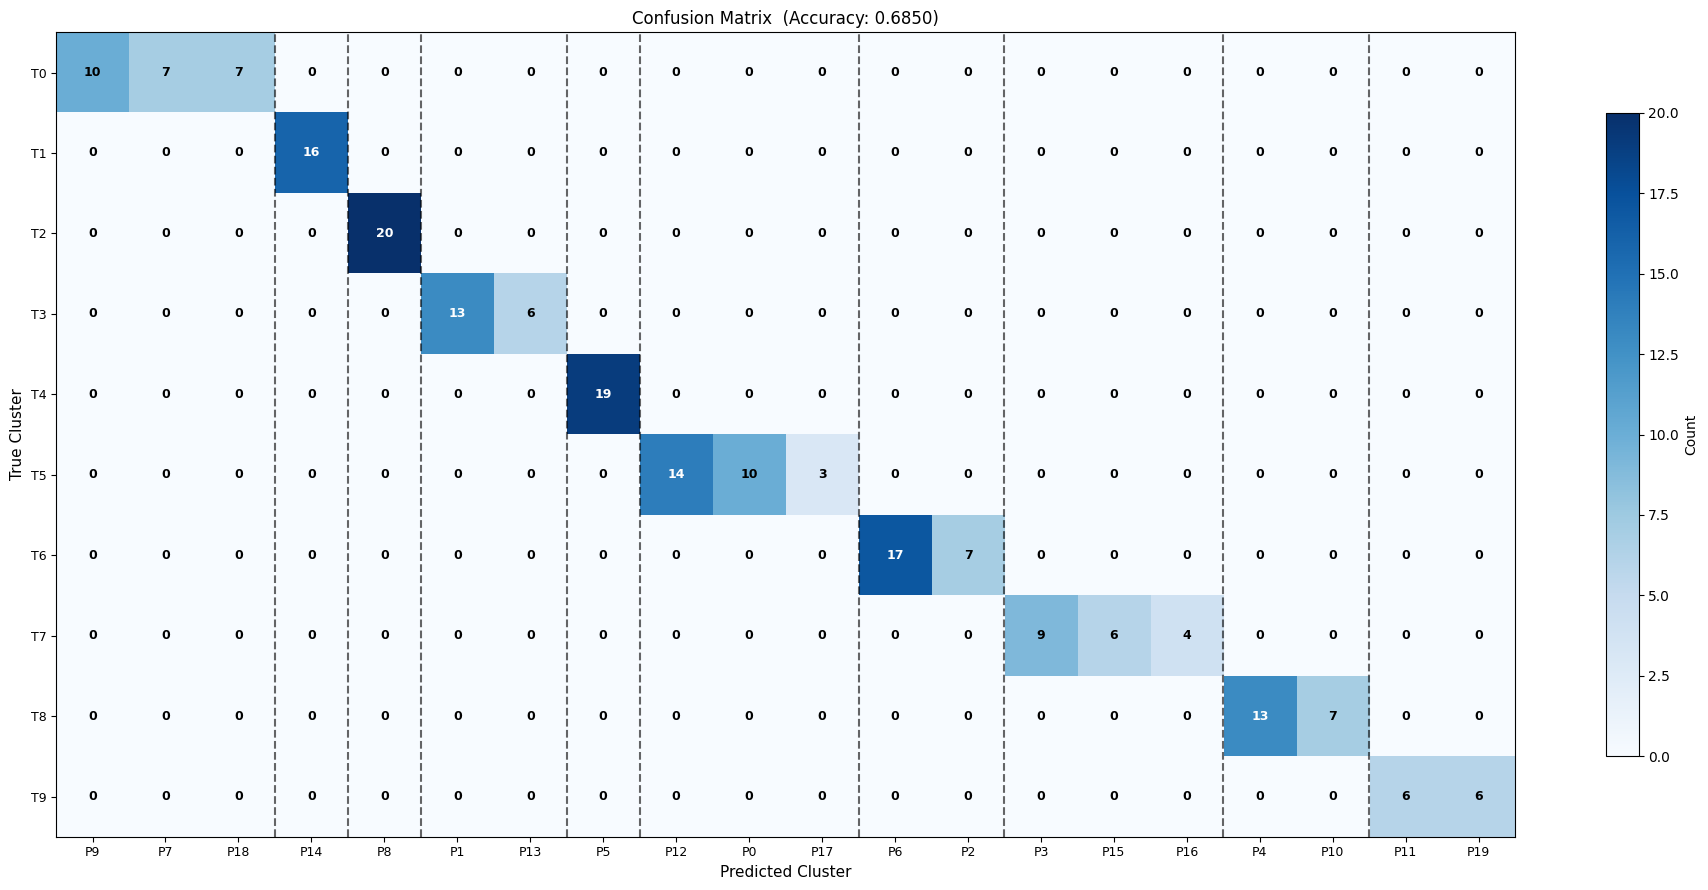

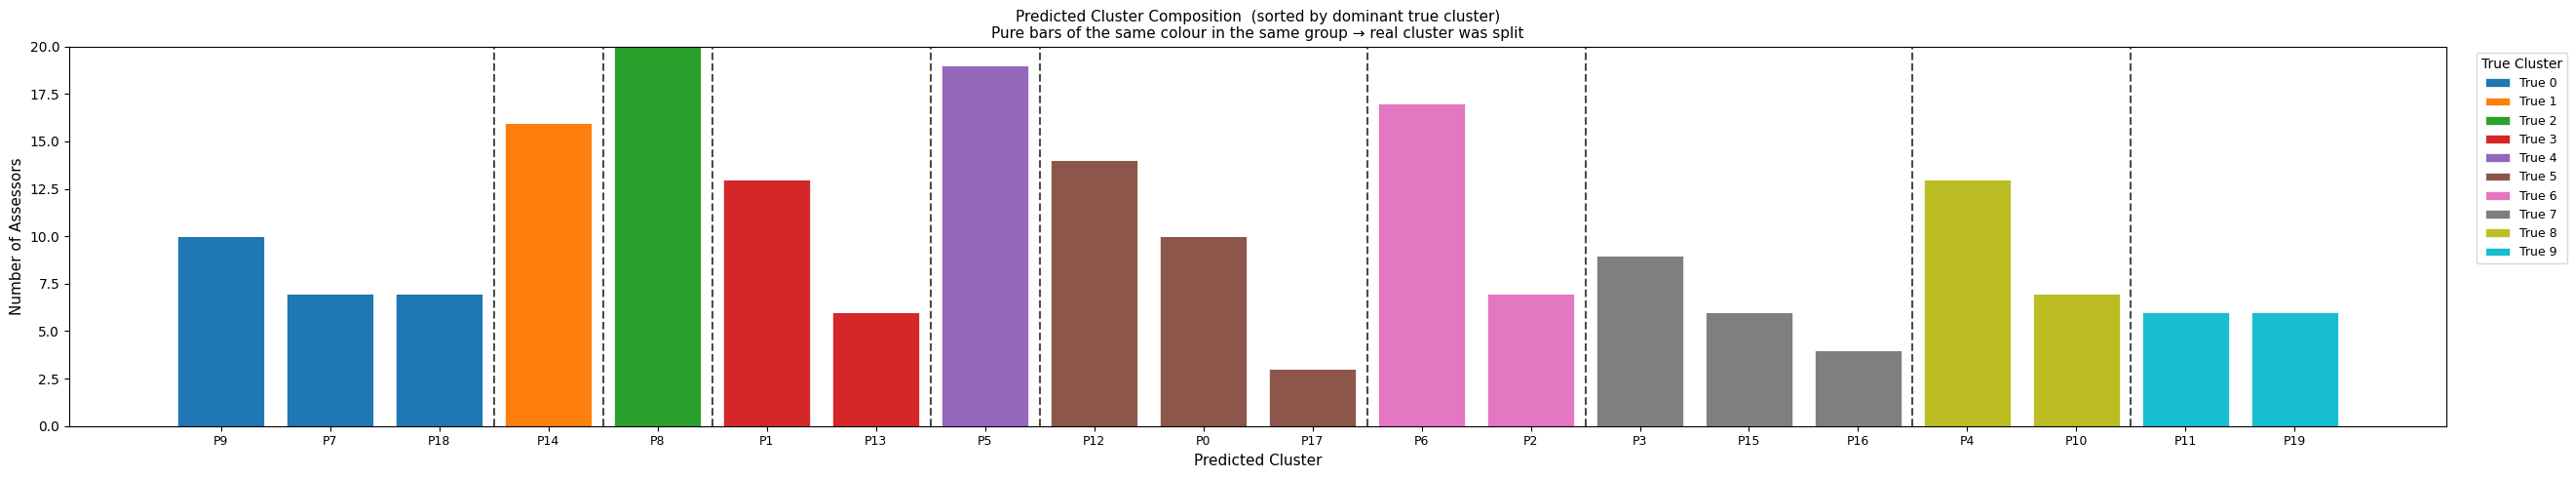

In [9]:

import matplotlib.pyplot as plt
import numpy as np

# ── Label alignment ──
pred_to_true, confusion_matrix, z_init_aligned, clustering_accuracy = match_clusters(z_true, z_init)
print(f"Clustering accuracy: {clustering_accuracy:.4f}  |  C_true={C_true}, C_init={C}")
print(f"Label mapping (pred -> true): {pred_to_true}")

z_true_arr = np.array(z_true)
z_pred_arr = np.array(z_init)
true_labels = np.unique(z_true_arr)
pred_labels = np.unique(z_pred_arr)
T, P = len(true_labels), len(pred_labels)
pred_to_idx = {p: j for j, p in enumerate(pred_labels)}

# ── Order predicted columns by dominant true cluster, then by size desc ──
# dominant_true[j] = row index of the true cluster with the highest count in column j
dominant_true = np.argmax(confusion_matrix, axis=0)   # shape (P,)
col_sizes      = confusion_matrix.max(axis=0)          # size of dominant segment

sorted_pred_col_order = sorted(
    range(P),
    key=lambda j: (dominant_true[j], -col_sizes[j])
)
col_order_preds    = [pred_labels[j] for j in sorted_pred_col_order]
confusion_ordered  = confusion_matrix[:, sorted_pred_col_order]

# ── Colour palette (one colour per true cluster) ──
cmap_tab10  = plt.get_cmap("tab10")
true_colors = {t: cmap_tab10(i % 10) for i, t in enumerate(true_labels)}

# ─────────────────────────────────────────────────────────────────
# 1. Confusion Matrix
#    Columns sorted so splits of the same true cluster appear together
# ─────────────────────────────────────────────────────────────────
fig_h = max(3.5, T * 0.75 + 1.5)
fig_w = max(5,   P * 0.85 + 2.0)
fig, ax = plt.subplots(figsize=(fig_w, fig_h))

im = ax.imshow(confusion_ordered.astype(float), cmap="Blues", aspect="auto")

max_val = confusion_ordered.max() if confusion_ordered.max() > 0 else 1
for i in range(T):
    for j in range(P):
        val = confusion_ordered[i, j]
        txt_color = "white" if val > max_val * 0.6 else "black"
        ax.text(j, i, str(val),
                ha="center", va="center", fontsize=9,
                fontweight="bold", color=txt_color)

# Dashed vertical separators between groups of the same dominant true cluster
grp = -1
for col_pos, j in enumerate(sorted_pred_col_order):
    if dominant_true[j] != grp:
        if col_pos > 0:
            ax.axvline(col_pos - 0.5, color="black", linewidth=1.5,
                       linestyle="--", alpha=0.6)
        grp = dominant_true[j]

ax.set_xticks(range(P))
ax.set_yticks(range(T))
ax.set_xticklabels([f"P{p}" for p in col_order_preds], fontsize=9)
ax.set_yticklabels([f"T{t}" for t in true_labels],     fontsize=9)
ax.set_xlabel("Predicted Cluster", fontsize=11)
ax.set_ylabel("True Cluster",      fontsize=11)
ax.set_title(f"Confusion Matrix  (Accuracy: {clustering_accuracy:.4f})", fontsize=12)
plt.colorbar(im, ax=ax, label="Count", shrink=0.8)
plt.tight_layout()
plt.show()

# ─────────────────────────────────────────────────────────────────
# 2. Predicted cluster composition (stacked bar chart)
#    Same column order as the confusion matrix.
#    A pure-coloured bar = that predicted cluster is entirely one true cluster.
#    Two pure bars of the same colour within the same dashed-line group
#    means a real cluster was split in two.
# ─────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(max(6, P * 1.2 + 2.5), 5))

x       = np.arange(P)
bottoms = np.zeros(P)

for t_lbl in true_labels:
    counts = np.array([
        np.sum((z_pred_arr == p) & (z_true_arr == t_lbl))
        for p in col_order_preds
    ])
    ax.bar(x, counts, bottom=bottoms,
           color=true_colors[t_lbl],
           label=f"True {t_lbl}",
           edgecolor="white", linewidth=0.5)
    bottoms += counts

# Same dashed separators as the confusion matrix
grp = -1
for col_pos, j in enumerate(sorted_pred_col_order):
    if dominant_true[j] != grp:
        if col_pos > 0:
            ax.axvline(col_pos - 0.5, color="black", linewidth=1.5,
                       linestyle="--", alpha=0.7)
        grp = dominant_true[j]

ax.set_xticks(x)
ax.set_xticklabels([f"P{p}" for p in col_order_preds], fontsize=9)
ax.set_xlabel("Predicted Cluster", fontsize=11)
ax.set_ylabel("Number of Assessors", fontsize=11)
ax.set_title(
    "Predicted Cluster Composition  (sorted by dominant true cluster)\n"
    "Pure bars of the same colour in the same group → real cluster was split",
    fontsize=11
)
ax.legend(title="True Cluster",
          bbox_to_anchor=(1.01, 1), loc="upper left", fontsize=9)
plt.tight_layout()
plt.show()


  p_est Tie Detection (q > 0.5)  vs. True Ties
  Cluster   True    Est    TP    FP    FN   Prec    Rec     F1
--------------------------------------------------------------
   T0↔P11    254   2203    60  2143   194  0.027  0.236  0.049
   T1↔P10    238   3850    94  3756   144  0.024  0.395  0.046
    T2↔P2    236   2945    79  2866   157  0.027  0.335  0.050
   T3↔P12    175   3804    69  3735   106  0.018  0.394  0.035
    T4↔P9    193   2210    57  2153   136  0.026  0.295  0.047
    T5↔P6    183   3826    76  3750   107  0.020  0.415  0.038
    T6↔P4    159   2371    54  2317   105  0.023  0.340  0.043
   T7↔P13    191   1012    25   987   166  0.025  0.131  0.042
    T8↔P1    180   3943    79  3864   101  0.020  0.439  0.038
    T9↔P3    237   2934    83  2851   154  0.028  0.350  0.052

--- True cluster 0 ↔ Pred cluster 11 ---
  Missed true ties (194):  ... and 186 more
  (0,105): q=0.020
  (0,141): q=0.145
  (1,51): q=0.265
  (1,137): q=0.020
  (2,18): q=0.265
  (2,28): q=0.391


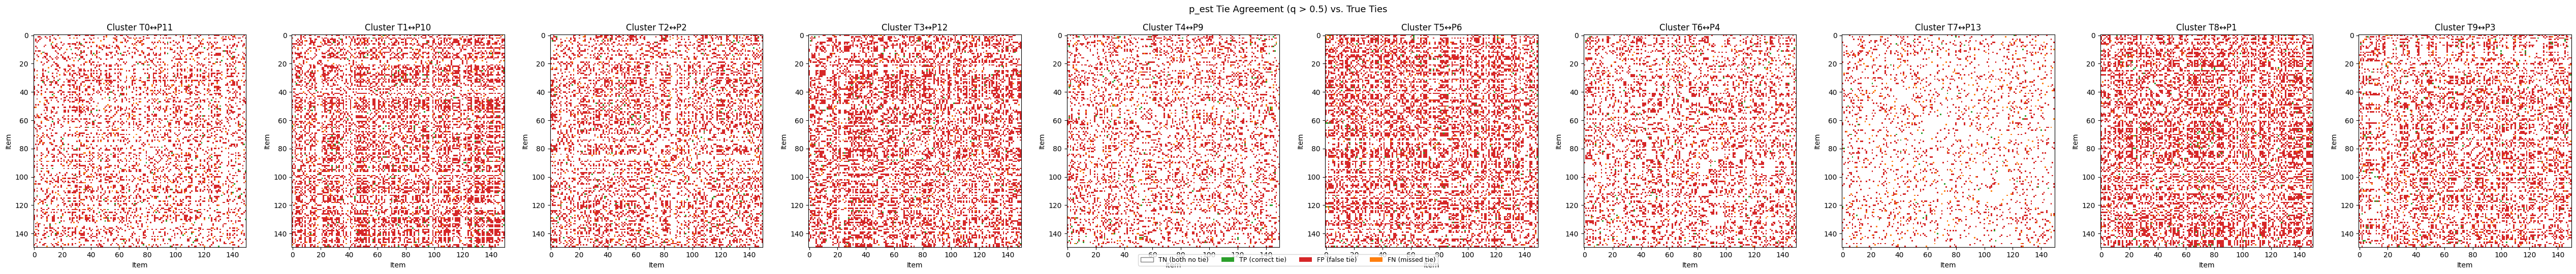

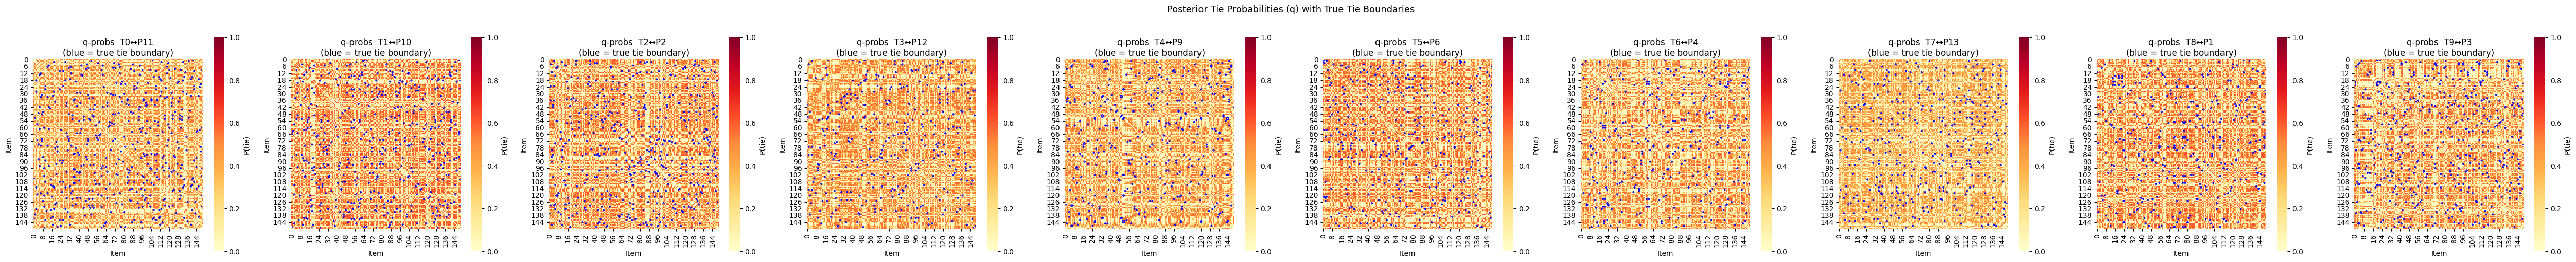

In [9]:
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.patches import Patch

# ─────────────────────────────────────────────────────────────────
# Pre-MCMC tie analysis: p_est q-probabilities vs. true ties
# Only depends on: p_est, pred_to_true, true_blocks, n_items, C_true
# ─────────────────────────────────────────────────────────────────

Q_THRESHOLD = 0.5  # threshold for calling a tie from q-probabilities

def get_tied_pairs(weak_order):
    """Return set of (min, max) pairs that share a block."""
    tied = set()
    for block in weak_order:
        for a in range(len(block)):
            for b in range(a + 1, len(block)):
                tied.add(tuple(sorted([block[a], block[b]])))
    return tied

def block_to_tie_matrix(blocks, n):
    """Convert block structure to an n×n binary tie matrix."""
    M = np.zeros((n, n), dtype=int)
    for pair in get_tied_pairs(blocks):
        M[pair] = 1
        M[pair[1], pair[0]] = 1
    return M

# ── Align p_est q-matrices to true clusters ──
true_to_pred = {t: p for p, t in pred_to_true.items()}
det = p_est.get("details", {})

tie_data = []
for c_true in range(C_true):
    c_pred = true_to_pred.get(c_true)
    true_mat = block_to_tie_matrix(true_blocks[c_true], n_items)
    true_pairs = get_tied_pairs(true_blocks[c_true])

    q_mat = None
    q_est_mat = np.zeros((n_items, n_items), dtype=int)
    q_est_pairs = set()

    if c_pred is not None and c_pred in det:
        q_mat = det[c_pred]["q"]
        # Threshold q-matrix to get estimated ties
        for i in range(n_items):
            for j in range(i + 1, n_items):
                if q_mat[i, j] > Q_THRESHOLD:
                    q_est_pairs.add((i, j))
                    q_est_mat[i, j] = 1
                    q_est_mat[j, i] = 1

    tie_data.append({
        "c_true": c_true, "c_pred": c_pred,
        "true_mat": true_mat, "true_pairs": true_pairs,
        "q_mat": q_mat, "q_est_mat": q_est_mat, "q_est_pairs": q_est_pairs,
    })

# ─────────────────────────────────────────────────────────────────
# 1. Summary table: precision / recall / F1 per cluster
# ─────────────────────────────────────────────────────────────────
print("=" * 72)
print(f"  p_est Tie Detection (q > {Q_THRESHOLD})  vs. True Ties")
print("=" * 72)
header = f"{'Cluster':>9} {'True':>6} {'Est':>6} {'TP':>5} {'FP':>5} {'FN':>5} {'Prec':>6} {'Rec':>6} {'F1':>6}"
print(header)
print("-" * len(header))

for d in tie_data:
    tp = len(d["true_pairs"] & d["q_est_pairs"])
    fp = len(d["q_est_pairs"] - d["true_pairs"])
    fn = len(d["true_pairs"] - d["q_est_pairs"])
    prec = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    rec  = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    f1   = 2 * prec * rec / (prec + rec) if (prec + rec) > 0 else 0.0

    label = f"T{d['c_true']}↔P{d['c_pred']}" if d["c_pred"] is not None else f"T{d['c_true']}↔ —"
    print(f"{label:>9} {len(d['true_pairs']):>6} {len(d['q_est_pairs']):>6} {tp:>5} {fp:>5} {fn:>5} {prec:>6.3f} {rec:>6.3f} {f1:>6.3f}")

print()

# Representative examples (limit output for large n)
MAX_EXAMPLES = 8
for d in tie_data:
    fn_pairs = sorted(d["true_pairs"] - d["q_est_pairs"])
    fp_pairs = sorted(d["q_est_pairs"] - d["true_pairs"])
    tp_pairs = sorted(d["true_pairs"] & d["q_est_pairs"])

    label = f"True cluster {d['c_true']} ↔ Pred cluster {d['c_pred']}"
    print(f"--- {label} ---")
    q = d["q_mat"]
    if fn_pairs:
        shown = fn_pairs[:MAX_EXAMPLES]
        extra = f"  ... and {len(fn_pairs) - MAX_EXAMPLES} more" if len(fn_pairs) > MAX_EXAMPLES else ""
        detail = "".join(f"  ({i},{j}): q={q[i,j]:.3f}\n" for i,j in shown) if q is not None else ""
        print(f"  Missed true ties ({len(fn_pairs)}):{extra}\n{detail}" if detail else f"  Missed true ties ({len(fn_pairs)}): {shown}{extra}")
    else:
        print("  Missed true ties: none")

    if fp_pairs:
        shown = fp_pairs[:MAX_EXAMPLES]
        extra = f"  ... and {len(fp_pairs) - MAX_EXAMPLES} more" if len(fp_pairs) > MAX_EXAMPLES else ""
        detail = "".join(f"  ({i},{j}): q={q[i,j]:.3f}\n" for i,j in shown) if q is not None else ""
        print(f"  False ties ({len(fp_pairs)}):{extra}\n{detail}" if detail else f"  False ties ({len(fp_pairs)}): {shown}{extra}")
    else:
        print("  False ties: none")

    if tp_pairs:
        shown = tp_pairs[:MAX_EXAMPLES]
        extra = f"  ... and {len(tp_pairs) - MAX_EXAMPLES} more" if len(tp_pairs) > MAX_EXAMPLES else ""
        print(f"  Correct ties ({len(tp_pairs)}){extra}")
    else:
        print("  Correct ties: none")
    print()


# ─────────────────────────────────────────────────────────────────
# 2. Agreement heatmaps: q-threshold ties vs. true ties
# ─────────────────────────────────────────────────────────────────
agreement_cmap = mcolors.ListedColormap(["white", "#2ca02c", "#d62728", "#ff7f0e"])
agreement_bounds = [-0.5, 0.5, 1.5, 2.5, 3.5]
agreement_norm = mcolors.BoundaryNorm(agreement_bounds, agreement_cmap.N)
legend_patches = [
    Patch(facecolor="white", edgecolor="grey", label="TN (both no tie)"),
    Patch(facecolor="#2ca02c", label="TP (correct tie)"),
    Patch(facecolor="#d62728", label="FP (false tie)"),
    Patch(facecolor="#ff7f0e", label="FN (missed tie)"),
]

fig, axes = plt.subplots(1, C_true, figsize=(5 * C_true + 1, 5), squeeze=False)
for idx, d in enumerate(tie_data):
    ax = axes[0, idx]
    agree = np.zeros((n_items, n_items), dtype=int)
    agree[(d["true_mat"] == 1) & (d["q_est_mat"] == 1)] = 1  # TP
    agree[(d["true_mat"] == 0) & (d["q_est_mat"] == 1)] = 2  # FP
    agree[(d["true_mat"] == 1) & (d["q_est_mat"] == 0)] = 3  # FN

    ax.imshow(agree, cmap=agreement_cmap, norm=agreement_norm, interpolation="nearest")
    ax.set_title(f"Cluster T{d['c_true']}↔P{d['c_pred']}")
    ax.set_xlabel("Item")
    ax.set_ylabel("Item")

fig.legend(handles=legend_patches, loc="lower center", ncol=4,
           bbox_to_anchor=(0.5, -0.02), fontsize=9)
fig.suptitle(f"p_est Tie Agreement (q > {Q_THRESHOLD}) vs. True Ties", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()


# ─────────────────────────────────────────────────────────────────
# 3. q-probability heatmaps with true tie boundary overlay
# ─────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, C_true, figsize=(5 * C_true + 1, 5), squeeze=False)
for idx, d in enumerate(tie_data):
    ax = axes[0, idx]
    q = d["q_mat"]
    if q is not None:
        sns.heatmap(q, vmin=0, vmax=1, cmap="YlOrRd", ax=ax,
                    cbar_kws={"label": "P(tie)"}, square=True)
        # Overlay true tie contours
        if d["true_pairs"]:
            contour_mat = d["true_mat"].astype(float)
            ax.contour(np.arange(n_items) + 0.5, np.arange(n_items) + 0.5,
                       contour_mat, levels=[0.5], colors="blue", linewidths=1.5)
        ax.set_title(f"q-probs  T{d['c_true']}↔P{d['c_pred']}\n(blue = true tie boundary)")
    else:
        ax.text(0.5, 0.5, "No q-matrix", ha="center", va="center",
                transform=ax.transAxes, fontsize=12)
        ax.set_title(f"Cluster T{d['c_true']}")
    ax.set_xlabel("Item")
    ax.set_ylabel("Item")

fig.suptitle("Posterior Tie Probabilities (q) with True Tie Boundaries", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

In [ ]:
# ---- MCMC settings ----
#init_mu = [1/(2*C) for _ in range(C)]   # Use small priors with overfitted model to obtain optimal clustering
init_mu = [n_assessors/C for _ in range(C)]   # Use larger priors to not overfit to one cluster

model = MixtureRankingModel(rankings,
                                n_clusters=C,
                                #init_clusters=clusters,
                                #init_z=z_init,
                                init_mu=init_mu,
                                seed=42,
                                verbose=True,
                                init_theta=1.0,
                                )

# when calling run_mcmc you can override PY parameters via sampler kwargs
# here we also activate the new PY-prior MH move with p_py>0
final_state, samples = model.run_mcmc(
    n_iter=15000,
    burn_in=10000,  
    thin=2,
    save_samples=True,
    save_tau=True,
    save_theta=True,
    n_item_moves_per_cluster=2,
    gamma=gamma,        # global gamma override (optional)
    delta=delta,        # global delta override (optional)
    a_theta=4,
    b_theta=1,
    theta_jump=10,
    use_annealing=True,
    temp_min=0.25,
    temp_max=1.0,
    tie_penalty=p_hat,
)

if samples is not None:
    summaries = model.estimate_map(samples, ci=0.95)
    print("MAP-like summaries:", summaries)

C:\Users\Bruker\AppData\Local\Temp\ipykernel_16996\1942945823.py:5: UserWarning: init_clusters not provided. For best results supply them via init_spectral_with_z(rankings, n_clusters=C, seed=...). Falling back to trivial initialization.
  model = MixtureRankingModel(rankings,


[Model] Initialized: N=200 assessors, n=150 items, C=20 clusters, n_pairs=11,175
[Model] Compute:  CPU  (GPU unavailable — torch not installed)
[Model] U_all:    200×11,175  (8.5 MB float32, on CPU)
[Model] Parallel: N threshold = disabled
  Cluster 0: 75 blocks, theta=1.000, gamma=1.000, delta=0.500
  Cluster 1: 75 blocks, theta=1.000, gamma=1.000, delta=0.500
  Cluster 2: 75 blocks, theta=1.000, gamma=1.000, delta=0.500
  Cluster 3: 75 blocks, theta=1.000, gamma=1.000, delta=0.500
  Cluster 4: 75 blocks, theta=1.000, gamma=1.000, delta=0.500
  Cluster 5: 75 blocks, theta=1.000, gamma=1.000, delta=0.500
  Cluster 6: 75 blocks, theta=1.000, gamma=1.000, delta=0.500
  Cluster 7: 75 blocks, theta=1.000, gamma=1.000, delta=0.500
  Cluster 8: 75 blocks, theta=1.000, gamma=1.000, delta=0.500
  Cluster 9: 75 blocks, theta=1.000, gamma=1.000, delta=0.500
  Cluster 10: 75 blocks, theta=1.000, gamma=1.000, delta=0.500
  Cluster 11: 75 blocks, theta=1.000, gamma=1.000, delta=0.500
  Cluster 12: 

In [11]:
import pickle

file_name = "model_2.pkl"

# Save
with open(file_name, "wb") as f:
    pickle.dump({"model": final_state, "samples": samples}, f)

# Load
with open(file_name, "rb") as f:
    data = pickle.load(f)
    final_state, samples = data["model"], data["samples"]

In [12]:
model.print_acceptance_summary()


MCMC ACCEPTANCE SUMMARY

Log-posterior improvements: 1264/2499
Log-posterior improvement rate: 50.58%

Block moves acceptance (saved iterations = 2500):
  Cluster 0: 2033 accepts, acceptance_rate=81.32%
  Cluster 1: 2142 accepts, acceptance_rate=85.68%
  Cluster 2: 0 accepts, acceptance_rate=0.00%
  Cluster 3: 0 accepts, acceptance_rate=0.00%
  Cluster 4: 0 accepts, acceptance_rate=0.00%
  Cluster 5: 0 accepts, acceptance_rate=0.00%
  Cluster 6: 2115 accepts, acceptance_rate=84.60%
  Cluster 7: 1643 accepts, acceptance_rate=65.72%
  Cluster 8: 0 accepts, acceptance_rate=0.00%
  Cluster 9: 0 accepts, acceptance_rate=0.00%
  Cluster 10: 2205 accepts, acceptance_rate=88.20%
  Cluster 11: 2105 accepts, acceptance_rate=84.20%
  Cluster 12: 0 accepts, acceptance_rate=0.00%
  Cluster 13: 0 accepts, acceptance_rate=0.00%
  Cluster 14: 2068 accepts, acceptance_rate=82.72%
  Cluster 15: 2193 accepts, acceptance_rate=87.72%
  Cluster 16: 0 accepts, acceptance_rate=0.00%
  Cluster 17: 0 accepts, 

In [12]:
if samples is not None:
        summaries = model.estimate_map(samples, ci=0.95)
        print("MAP-like summaries:", summaries)

MAP-like summaries: {'N': 500, 'C': 20, 'T': 2500, 'labels': {'p_ic': [[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0], [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0], [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0], [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0], [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0], [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0], [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0], [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0], [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0], [0.0, 0.0, 

In [13]:
# Fra BTMM
z_map = summaries["labels"]["z_hat"]
pred_to_true, M, z_aligned, acc = match_clusters(z_true, z_map)

print("accuracy after relabel:", acc)
print("contingency:\n", M)

accuracy after relabel: 0.905
contingency:
 [[ 0  0  0  0  0  0 24  0  0]
 [ 0  0 16  0  0  0  0  0  0]
 [20  0  0  0  0  0  0  0  0]
 [ 0  0  0  0 19  0  0  0  0]
 [ 0  0  0 19  0  0  0  0  0]
 [ 0  0  0  0  0  0  0  0 27]
 [ 0  0  0  0  0 24  0  0  0]
 [ 0  0  0 19  0  0  0  0  0]
 [ 0 20  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0 12  0]]


In [14]:
# Fra spectral clustering
z_map = summaries["labels"]["z_hat"]
pred_to_true, M, z_aligned, acc = match_clusters(z_true, z_init)
print("accuracy after relabel:", acc)
print("contingency:\n", M)

accuracy after relabel: 0.53
contingency:
 [[ 0  0  0  0  0 11  0  0  0  0  0 24  0  0  0  0 13  0  0  0]
 [ 0  0  0  0  0  0  3  0  0  0 40  0  0  0  0  0  0  0  0  8]
 [ 0  0 25  0  0  3  0  0  0  0  0  0  0  0 10  0  2  0 13  0]
 [22  0  0  0  0  3  0  0  0  0  0  0 23  0  9  0  0  0  0  0]
 [ 0  0  0  0  0  0  4  0 18 23  0  0  0  0  0  0  1  0  0  0]
 [ 2  0  0  0  0  0 28 13  0  0  0  0  0  0  0  0  0 16  0  0]
 [ 0  0  0  0 29  4  0  7  0  0  0  0  0  0  0 11  0  0  0  0]
 [ 0 11 10  0  0  0  3  0  0  1  2  0  3 16  0  0  0  0  0  5]
 [ 0 27  1  0  0  0  0  0  0  0  0  0  0  0  4  0  0  0  0  8]
 [ 0  0  0 30  0  5  0  0  0  0  0  0  0  0  0  0  0  0  0  9]]


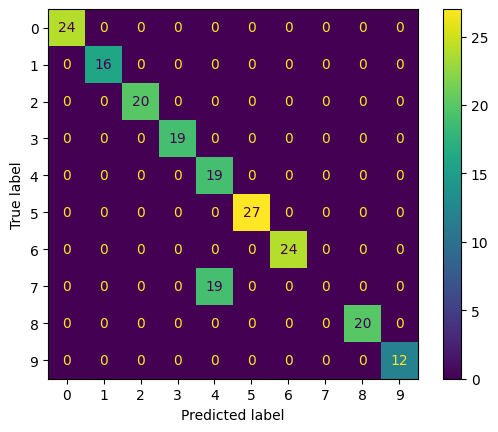

In [14]:
disp = ConfusionMatrixDisplay.from_predictions(z_true, z_aligned)

In [15]:
map_result = model.find_map(samples, refine=True, verbose=True)

# Output:
# [MAP] Best sample at t=1234 with logp=-5432.10
#   Cluster 0: 12 moves in 3 sweeps, K=4 blocks
#   Cluster 1: 8 moves in 2 sweeps, K=3 blocks
# [MAP] logp: -5432.10 → -5428.55 (Δ=+3.55)

for c, cl in enumerate(map_result["clusters"]):
    print(f"Cluster {c}: {cl['blocks']}")

[MAP] Best sample at t=1343 with logp=-102467.3858
  Cluster 0: 89 moves in 3 sweeps, K=13 blocks
  Cluster 1: 94 moves in 6 sweeps, K=13 blocks
  Cluster 6: 167 moves in 50 sweeps, K=12 blocks
  Cluster 7: 64 moves in 5 sweeps, K=8 blocks
  Cluster 10: 91 moves in 5 sweeps, K=14 blocks
  Cluster 11: 73 moves in 4 sweeps, K=13 blocks
  Cluster 14: 180 moves in 50 sweeps, K=14 blocks
  Cluster 15: 87 moves in 6 sweeps, K=13 blocks
  Cluster 18: 70 moves in 4 sweeps, K=14 blocks
[MAP] logp: -102467.3858 → -101283.7314 (Δ=+1183.6544)
Cluster 0: [[19, 50, 84, 93, 95], [20, 25, 26, 37, 49, 51, 54, 56, 69, 73, 92, 98, 107, 108, 128, 133, 136], [24, 33, 39, 71, 91, 116, 122], [10, 13, 15, 18, 23, 28, 29, 40, 47, 48, 65, 77, 78, 80, 82, 83, 96, 100, 103, 125, 138, 147], [1, 16, 35, 52, 53, 60, 76, 81, 99, 109, 115, 118, 131, 137, 148], [27, 36, 41, 62, 101, 111, 113, 124, 139, 141, 142], [2, 8, 30, 55, 70, 79, 102, 119, 126, 129, 132, 134, 140], [6, 22, 34, 44, 59, 61, 145], [0, 3, 4, 9, 14, 4

In [ ]:

import matplotlib.pyplot as plt
import numpy as np

TOP_K = 15        # top rank positions shown per cluster
# Optional: supply a list of item names of length n_items, e.g. item_names = [...]
# If None, items are labelled by their integer index.
item_names = None  # e.g. list of strings length n_items

# ── Infer active cluster count from MAP ───────────────────────────────────────
z_map_arr    = np.array(map_result["z"], dtype=int)
N_assessors  = len(z_map_arr)
C_map        = len(map_result["clusters"])
active_mask  = [i for i in range(C_map) if (z_map_arr == i).any()]

# ── Posterior confidence ──────────────────────────────────────────────────────
T_samp  = len(samples.z_samples)
N_samp  = len(map_result["z"])
cnt_arr = np.zeros((N_samp, C_map), dtype=np.float32)
for z_ in samples.z_samples:
    for i, c_ in enumerate(z_):
        cnt_arr[i, c_] += 1
cnt_arr /= T_samp
confidence = cnt_arr[np.arange(N_samp), z_map_arr]   # P(MAP cluster | data)

# ── Sort active clusters by size (largest first) ──────────────────────────────
cluster_sizes = np.array([(z_map_arr == c).sum() for c in range(C_map)])
cluster_order = sorted(active_mask, key=lambda c: -cluster_sizes[c])

# ── Helper: top-K items from block structure ──────────────────────────────────
def top_k_items(blocks, k, names):
    rows, pos = [], 1
    for b_idx, block in enumerate(blocks):
        for d_idx in block:
            label = names[d_idx] if names else str(d_idx)
            rows.append((pos, b_idx, label))
        pos += len(block)
        if pos > k:
            break
    return [r for r in rows if r[0] <= k]

block_bg = ["#eef3fb", "#d4e6f2"]   # alternating tints per tied block

# ── Figure layout ─────────────────────────────────────────────────────────────
ncols = len(cluster_order)
fig, axes = plt.subplots(
    2, ncols,
    figsize=(ncols * 2.4, 2.4 + TOP_K * 0.37),
    gridspec_kw={"height_ratios": [1, TOP_K * 0.37]},
)
if ncols == 1:
    axes = axes.reshape(2, 1)

max_size = max(cluster_sizes[c] for c in cluster_order)

for col, c in enumerate(cluster_order):
    cl       = map_result["clusters"][c]
    blocks   = cl["blocks"]
    theta    = float(cl.get("theta", float("nan")))
    n_c      = int(cluster_sizes[c])
    top_rows = top_k_items(blocks, TOP_K, item_names)

    # ── Top strip: horizontal bar = cluster size, θ annotated ────────────────
    ax_s = axes[0, col]
    ax_s.barh(0, n_c, color="#4a90d9", height=0.6, linewidth=0)
    ax_s.set_xlim(0, max_size * 1.1)
    ax_s.set_ylim(-0.6, 0.6)
    ax_s.axis("off")
    ax_s.set_title(
        f"Cluster {c}\nn={n_c}  θ={theta:.2f}",
        fontsize=7.5, pad=2, linespacing=1.5,
    )

    # ── Ranking list ──────────────────────────────────────────────────────────
    ax_r = axes[1, col]
    ax_r.set_xlim(0, 1)
    ax_r.set_ylim(0, len(top_rows))
    ax_r.invert_yaxis()
    ax_r.axis("off")

    prev_block, toggle = -1, 0
    for row_i, (rank_pos, b_idx, label) in enumerate(top_rows):
        if b_idx != prev_block:
            toggle, prev_block = 1 - toggle, b_idx
        ax_r.add_patch(plt.Rectangle(
            (0, row_i), 1, 1,
            facecolor=block_bg[toggle], edgecolor="none", zorder=1,
        ))
        ax_r.text(0.05, row_i + 0.5, str(rank_pos),
                  fontsize=6, va="center", ha="left", color="#aaaaaa", zorder=2)
        short = label if len(str(label)) <= 17 else str(label)[:16] + "\u2026"
        ax_r.text(0.22, row_i + 0.5, short,
                  fontsize=6.8, va="center", ha="left", color="#1a1a1a", zorder=2)

fig.subplots_adjust(hspace=0.08, wspace=0.06)
fig.suptitle(
    f"MAP consensus rankings per cluster  —  top {TOP_K} items\n"
    "(shading = tied blocks  ·  bar = number of assessors  ·  θ = MAP concentration)",
    fontsize=10, y=1.01,
)
plt.show()


In [16]:
# Ensure label mapping exists for the current MAP clustering
if "pred_to_true" not in globals():
    pred_to_true, M, z_aligned, acc = match_clusters(z_true, z_map)

# Build true -> predicted mapping
true_to_pred = {t: p for p, t in pred_to_true.items()}

# Build quick lookup for MAP clusters by cluster id
map_clusters = {
    c: cl
    for c, cl in enumerate(map_result["clusters"])
}

for c_true, blocks_true in enumerate(true_blocks):
    c_pred = true_to_pred.get(c_true, None)

    if c_pred is not None and c_pred in map_clusters:
        cl = map_clusters[c_pred]
        blocks_hat = cl["blocks"]

        print(
            f"True cluster {c_true} ↔ Pred cluster {c_pred}\n"
            f"  TRUE blocks: {blocks_true}\n"
            f"  MAP blocks:  {blocks_hat}\n"
        )
    else:
        print(
            f"True cluster {c_true} ↔ Pred cluster None\n"
            f"  TRUE blocks: {blocks_true}\n"
            f"  MAP blocks:  None\n"
        )

True cluster 0 ↔ Pred cluster 14
  TRUE blocks: [[18, 35], [136], [82, 31, 27, 90, 139], [70, 118], [93, 78], [85, 36, 45, 110], [113, 97, 80, 2], [114, 61], [69, 0], [87, 103], [60, 10, 88, 16, 115], [72, 23], [24, 7, 120], [26, 112], [55, 39], [91, 147, 51, 57], [44, 141], [74], [122, 71, 6], [133, 50, 28], [126, 132], [48, 46], [79, 64, 109, 143], [53, 104, 63], [56, 119, 84, 5], [13, 42, 144, 106], [140, 123, 32, 1, 73], [12, 9, 94], [146, 135], [124], [25, 117], [41], [83, 65, 29, 107, 129], [38, 95, 43, 14], [125, 30, 17, 68], [40, 105, 108], [127, 138, 130, 54], [22, 137, 149], [15], [96, 89, 47, 58, 145], [102, 49, 34, 52], [33, 101, 148, 86, 77], [116, 99, 98, 100], [21, 67], [81, 59, 134], [66, 121], [3, 62, 142, 11], [111, 128, 131, 75], [4, 8, 37, 19], [76, 20, 92]]
  MAP blocks:  [[90], [18], [2, 27, 31, 35, 36, 45, 70, 78, 80, 82, 93, 110, 113, 118, 136, 139], [0, 10, 16, 60, 61, 69, 72, 85, 87, 97, 103, 114, 115], [7, 23, 24, 26, 39, 44, 51, 55, 57, 74, 88, 91, 112, 120]

In [17]:
ari = adjusted_rand_score(z_true, z_map)
print("ARI:", ari)

ARI: 0.9064350843726598


In [18]:
precision = precision_score(z_true, z_aligned, average='macro')
recall    = recall_score(z_true, z_aligned, average='macro')
f1        = f1_score(z_true, z_aligned,average='macro')

print(precision, recall, f1)


0.85 0.9 0.8666666666666666


c:\Users\Bruker\OneDrive\PhD\Kode\TiedBayesMallows\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


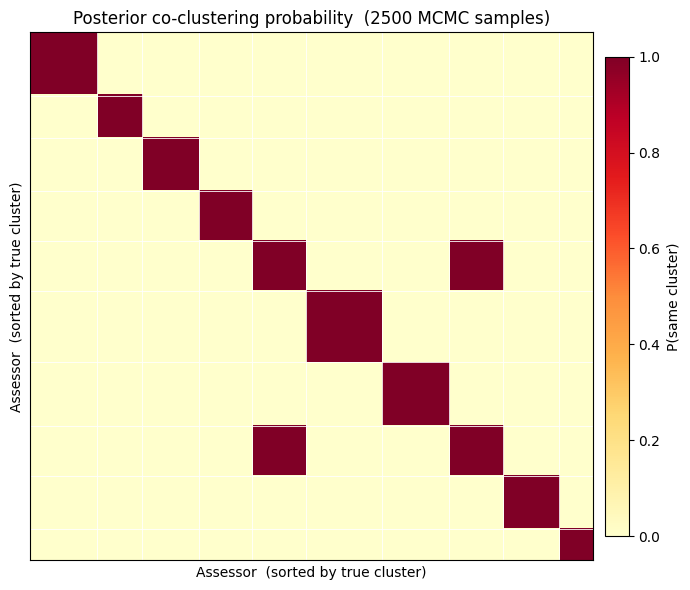

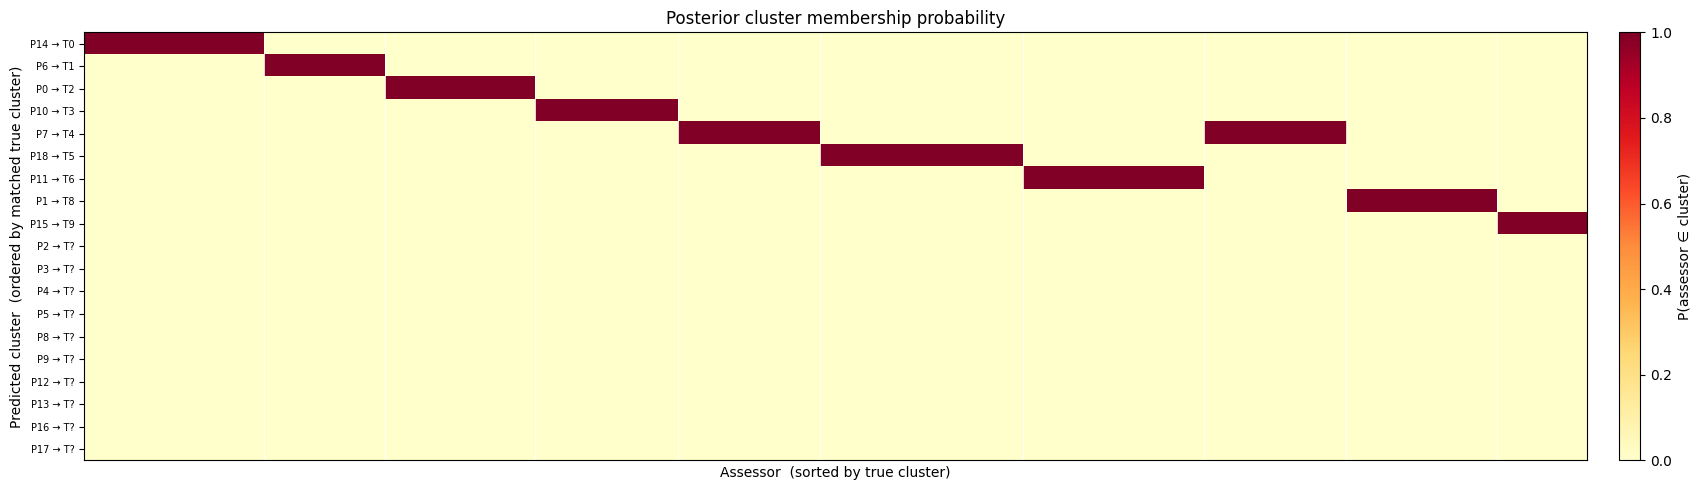

In [19]:

import numpy as np
import matplotlib.pyplot as plt

# ── Parse samples ─────────────────────────────────────────────────────────
z_arr          = np.array(samples.z_samples, dtype=np.intp)   # (T, N)
T_samp, N_samp = z_arr.shape
C_obs          = int(z_arr.max()) + 1
z_true_arr     = np.array(z_true, dtype=np.intp)

# Sort assessors by true cluster so the block diagonal is visible
sort_ord    = np.argsort(z_true_arr, kind='stable')
z_true_sort = z_true_arr[sort_ord]
boundaries  = np.where(np.diff(z_true_sort))[0]   # cluster border positions

# One-hot (T, N, C_obs) float32 — shared by both heatmaps
one_hot_f32 = (z_arr[:, :, None] == np.arange(C_obs)[None, None, :]).astype(np.float32)

# Co-clustering via BLAS: co[i,j] = P(z_i == z_j)
co_cluster = np.zeros((N_samp, N_samp), dtype=np.float32)
for c in range(C_obs):
    col = one_hot_f32[:, :, c].T           # (N, T)
    co_cluster += col @ col.T              # BLAS sgemm -> (N, N)
co_cluster /= T_samp

# Membership: membership[i, c] = P(z_i == c)
membership = one_hot_f32.mean(axis=0)      # (N, C_obs)
del one_hot_f32

co_sorted  = co_cluster[np.ix_(sort_ord, sort_ord)]
col_ord_m  = sorted(range(C_obs), key=lambda c: (pred_to_true.get(c, C_true + c), c))
mem_sorted = membership[sort_ord][:, col_ord_m]   # (N, C_obs)

# ═════════════════════════════════════════════════════════════════════════
#  PLOT 1  –  Co-clustering probability  (N × N heatmap)
#  Bright diagonal blocks  → assessors reliably share a cluster
#  Bright off-diagonal patches → two true clusters being merged, or one
#  true cluster being split across multiple predicted clusters
# ═════════════════════════════════════════════════════════════════════════
fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(co_sorted, vmin=0, vmax=1, cmap='YlOrRd',
               aspect='auto', interpolation='nearest')
for b in boundaries:
    ax.axvline(b + 0.5, color='white', lw=0.7, alpha=0.85)
    ax.axhline(b + 0.5, color='white', lw=0.7, alpha=0.85)
ax.set_xticks([]); ax.set_yticks([])
ax.set_xlabel('Assessor  (sorted by true cluster)')
ax.set_ylabel('Assessor  (sorted by true cluster)')
ax.set_title(f'Posterior co-clustering probability  ({T_samp} MCMC samples)')
plt.colorbar(im, ax=ax, label='P(same cluster)', fraction=0.04, pad=0.02)
plt.tight_layout()
plt.show()

# ═════════════════════════════════════════════════════════════════════════
#  PLOT 2  –  Cluster membership probability  (C × N heatmap)
#  Each row = one predicted cluster.  Columns = assessors sorted by true cluster.
#  A split true cluster → two rows lit up for the same column group.
#  A merged true cluster → two column groups lit up for the same row.
# ═════════════════════════════════════════════════════════════════════════
fig, ax = plt.subplots(figsize=(max(7, C_obs * 0.8 + 2), 5))
im = ax.imshow(mem_sorted.T, vmin=0, vmax=1, cmap='YlOrRd',
               aspect='auto', interpolation='nearest')
for b in boundaries:
    ax.axvline(b + 0.5, color='white', lw=0.7, alpha=0.85)
ax.set_xticks([])
ax.set_yticks(range(C_obs))
ax.set_yticklabels(
    [f'P{col_ord_m[j]} → T{pred_to_true.get(col_ord_m[j], "?")}' for j in range(C_obs)],
    fontsize=7)
ax.set_xlabel('Assessor  (sorted by true cluster)')
ax.set_ylabel('Predicted cluster  (ordered by matched true cluster)')
ax.set_title('Posterior cluster membership probability')
plt.colorbar(im, ax=ax, label='P(assessor ∈ cluster)', fraction=0.04, pad=0.02)
plt.tight_layout()
plt.show()


Precomputing per-cluster block indices for 10 clusters… done.


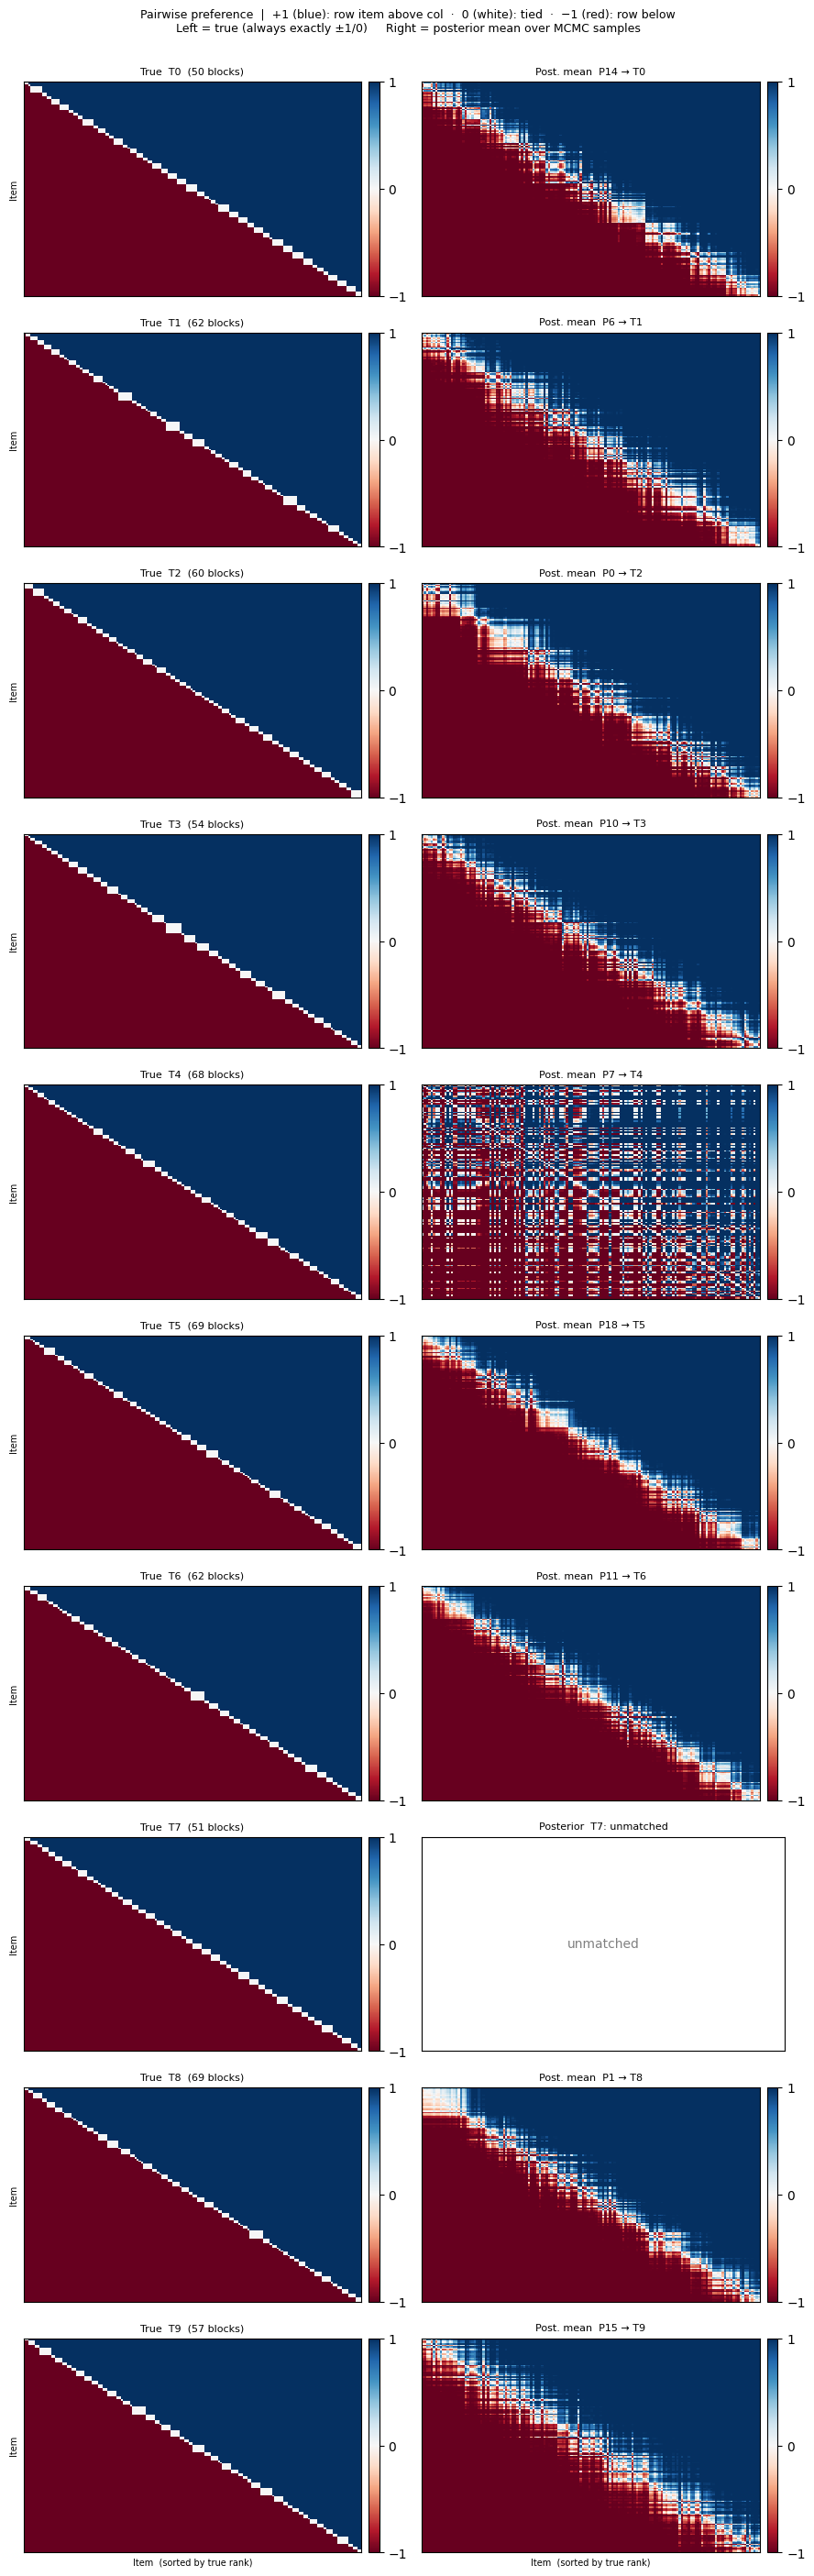

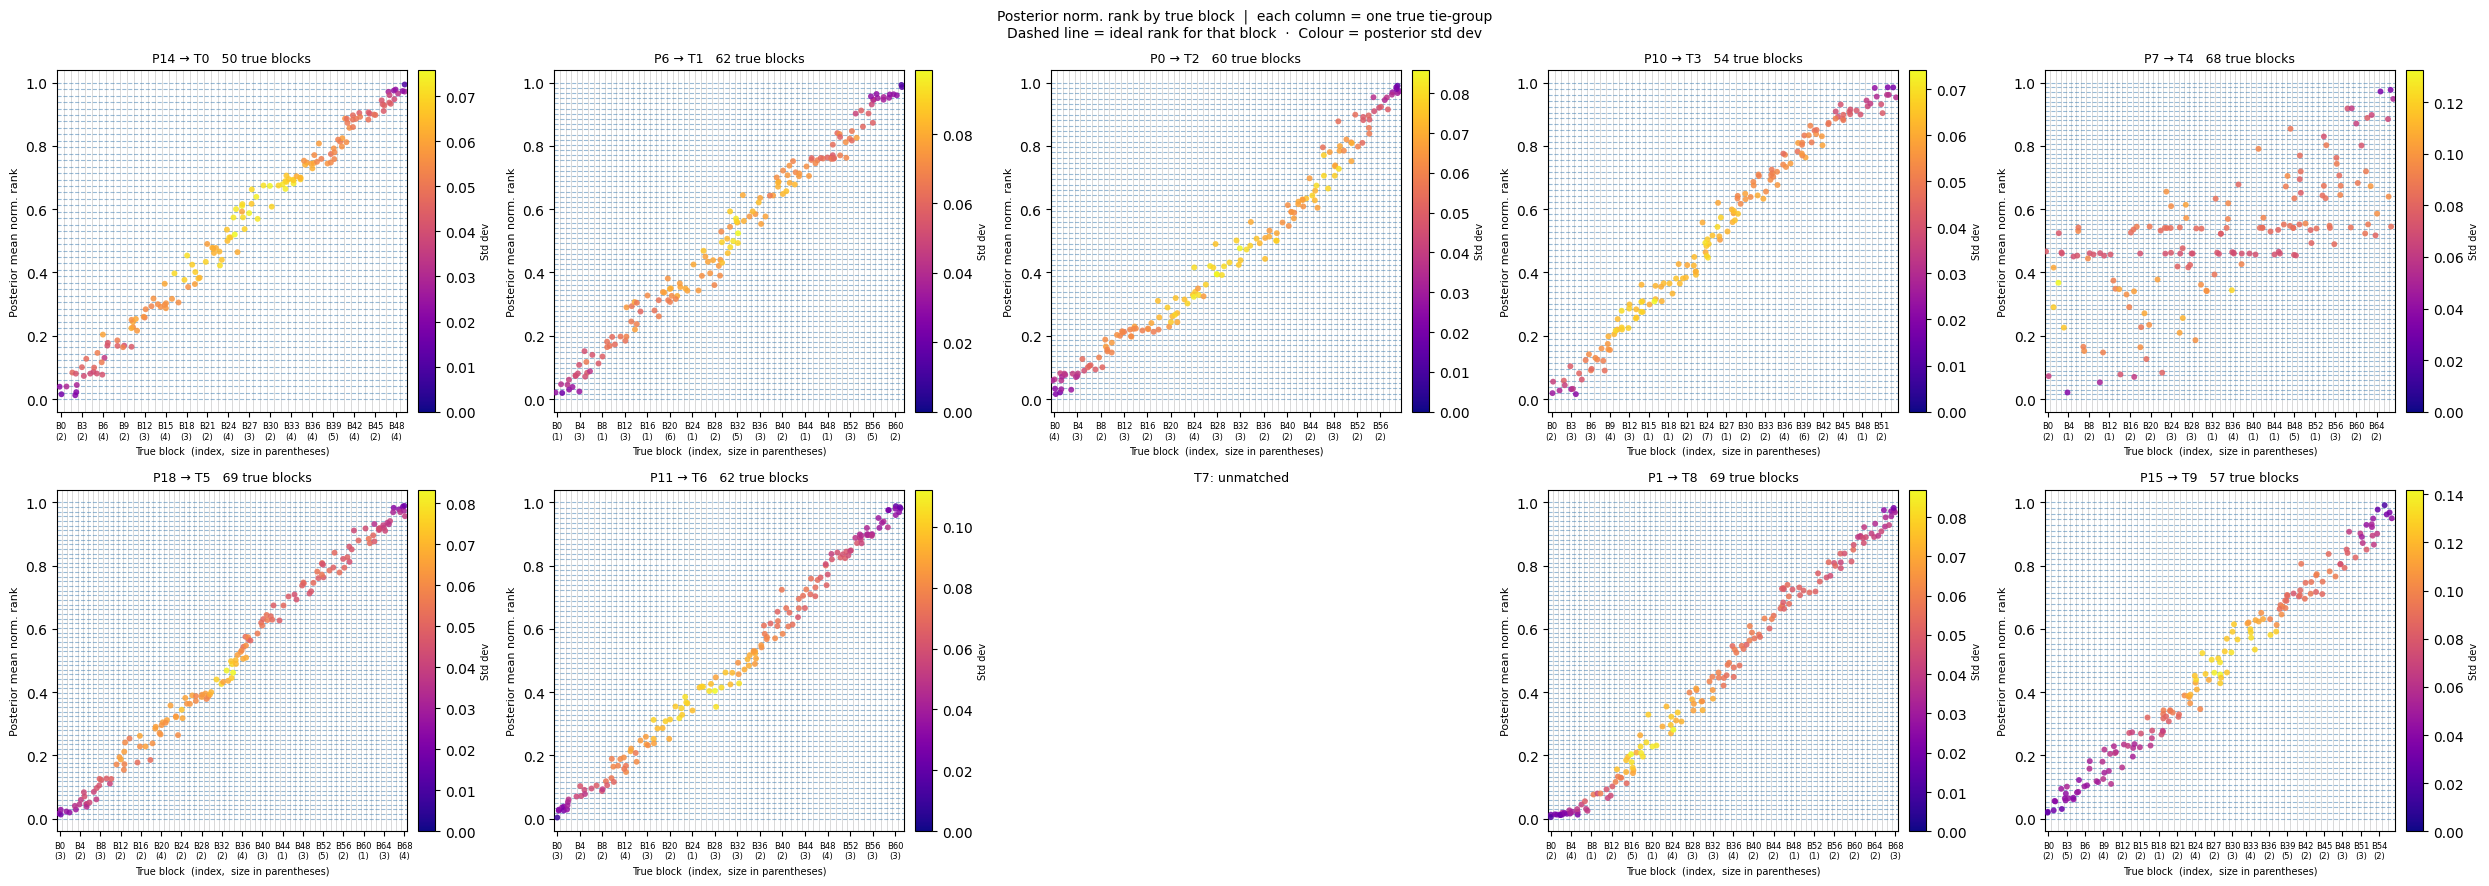

In [20]:

import math
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors

z_arr        = np.array(samples.z_samples, dtype=np.intp)   # (T, N)
T_samp       = z_arr.shape[0]
true_to_pred = {t: p for p, t in pred_to_true.items()}

# ── Helper: list-of-blocks → float64 item→block-index vector ─────────────
def _item_bk(blocks, n):
    a = np.zeros(n, dtype=np.float64)
    for k, blk in enumerate(blocks):
        a[np.asarray(blk, dtype=np.intp)] = k
    return a

# ── Precompute per-cluster posterior statistics ───────────────────────────
print(f"Precomputing per-cluster block indices for {C_true} clusters…", end=' ', flush=True)
cluster_stats = {}
for c_t in range(C_true):
    c_p = true_to_pred.get(c_t)
    if c_p is None:
        cluster_stats[c_t] = None
        continue

    ib_all = np.zeros((T_samp, n_items), dtype=np.float64)
    for t, blks_t in enumerate(samples.blocks_samples):
        for k, blk in enumerate(blks_t[c_p]):
            ib_all[t, np.asarray(blk, dtype=np.intp)] = k

    # pref_mean[i,j] = E[sign(bk_j - bk_i)];  +1 means i ranked above j
    pref_sum = np.zeros((n_items, n_items), dtype=np.float64)
    BATCH = 250
    for t0 in range(0, T_samp, BATCH):
        ib_b = ib_all[t0:t0 + BATCH]
        pref_sum += np.sign(ib_b[:, None, :] - ib_b[:, :, None]).sum(axis=0)
    pref_mean = pref_sum / T_samp

    K_arr = np.array([len(samples.blocks_samples[t][c_p]) for t in range(T_samp)])
    denom = np.where(K_arr > 1, K_arr - 1, 1.0)[:, None]
    nr_all = ib_all / denom
    nr_all[K_arr == 1] = 0.5
    nr_mean = nr_all.mean(axis=0)
    nr_std  = nr_all.std(axis=0)

    cluster_stats[c_t] = dict(c_pred=c_p, pref_mean=pref_mean,
                               nr_mean=nr_mean, nr_std=nr_std)
print("done.")

# ═════════════════════════════════════════════════════════════════════════
#  PLOT 3  –  Pairwise preference matrices; true (left) vs posterior mean (right)
#
#  pref[i,j] = +1 (blue)  : row item ranked strictly above col item
#            =  0 (white) : tied in the same block
#            = −1 (red)   : row item ranked below col item
# ═════════════════════════════════════════════════════════════════════════
fig_p, axes_p = plt.subplots(C_true, 2,
                              figsize=(9, 2.8 * C_true),
                              squeeze=False)
for c_t in range(C_true):
    ib_true   = _item_bk(true_blocks[c_t], n_items)
    item_sort = np.argsort(ib_true, kind='stable')
    pref_true = np.sign(ib_true[None, :] - ib_true[:, None])
    pt_sorted = pref_true[np.ix_(item_sort, item_sort)]

    ax_t = axes_p[c_t, 0]
    im_t = ax_t.imshow(pt_sorted, vmin=-1, vmax=1, cmap='RdBu',
                       aspect='auto', interpolation='nearest')
    ax_t.set_xticks([]); ax_t.set_yticks([])
    ax_t.set_title(f'True  T{c_t}  ({len(true_blocks[c_t])} blocks)', fontsize=8)
    ax_t.set_ylabel('Item', fontsize=7)
    if c_t == C_true - 1:
        ax_t.set_xlabel('Item  (sorted by true rank)', fontsize=7)
    plt.colorbar(im_t, ax=ax_t, fraction=0.05, pad=0.02, ticks=[-1, 0, 1])

    ax_p = axes_p[c_t, 1]
    st = cluster_stats[c_t]
    if st is None:
        ax_p.text(0.5, 0.5, 'unmatched', ha='center', va='center',
                  transform=ax_p.transAxes, fontsize=10, color='grey')
        ax_p.set_xticks([]); ax_p.set_yticks([])
        ax_p.set_title(f'Posterior  T{c_t}: unmatched', fontsize=8)
    else:
        pp_sorted = st['pref_mean'][np.ix_(item_sort, item_sort)]
        im_p = ax_p.imshow(pp_sorted, vmin=-1, vmax=1, cmap='RdBu',
                           aspect='auto', interpolation='nearest')
        ax_p.set_xticks([]); ax_p.set_yticks([])
        ax_p.set_title(f'Post. mean  P{st["c_pred"]} → T{c_t}', fontsize=8)
        if c_t == C_true - 1:
            ax_p.set_xlabel('Item  (sorted by true rank)', fontsize=7)
        plt.colorbar(im_p, ax=ax_p, fraction=0.05, pad=0.02, ticks=[-1, 0, 1])

fig_p.suptitle(
    'Pairwise preference  |  +1 (blue): row item above col  ·  0 (white): tied  ·  −1 (red): row below\n'
    'Left = true (always exactly ±1/0)     Right = posterior mean over MCMC samples',
    fontsize=9, y=1.002)
plt.tight_layout()
plt.show()

# ═════════════════════════════════════════════════════════════════════════
#  PLOT 4  –  Posterior rank recovery: strip plot grouped by true block
#
#  x-axis = true block index (0 = top, K-1 = bottom).  Items in the same
#  block are TIED in truth, so they share the same x column.  Horizontal
#  jitter separates them visually within each column.
#
#  y-axis = posterior mean normalised rank (0 = ranked first, 1 = last).
#
#  Dashed horizontal reference line = ideal posterior mean for that block,
#  i.e. k / (K_true - 1).  Items close to the reference line → correctly
#  recovered.  Inter-block spread on y → the model separated truly tied
#  items; intra-block spread → tied items placed at different ranks.
#
#  Colour = posterior std dev (brighter = more uncertain across samples).
# ═════════════════════════════════════════════════════════════════════════
ncols_r = min(C_true, 5)
nrows_r = math.ceil(C_true / ncols_r)
fig_r, axes_r = plt.subplots(nrows_r, ncols_r,
                              figsize=(max(5, ncols_r * 5.0), nrows_r * 4.5),
                              squeeze=False)

_rng_jitter = np.random.default_rng(0)   # reproducible horizontal jitter

for c_t in range(C_true):
    ax = axes_r[c_t // ncols_r, c_t % ncols_r]
    K_true     = len(true_blocks[c_t])
    st         = cluster_stats[c_t]

    if st is None:
        ax.set_title(f'T{c_t}: unmatched', fontsize=9)
        ax.axis('off')
        continue

    std_max = max(0.05, float(st['nr_std'].max()))
    norm_c  = mcolors.Normalize(vmin=0, vmax=std_max)
    sm      = cm.ScalarMappable(cmap='plasma', norm=norm_c)

    # Draw each true block as a column of jitter-spread dots
    JITTER_W = 0.35   # half-width of horizontal jitter band
    for k, blk in enumerate(true_blocks[c_t]):
        items    = np.asarray(blk, dtype=np.intp)
        nr_m     = st['nr_mean'][items]
        nr_s     = st['nr_std'][items]
        jitter   = _rng_jitter.uniform(-JITTER_W, JITTER_W, len(items))
        colors_k = sm.to_rgba(nr_s)
        ax.scatter(k + jitter, nr_m, color=colors_k,
                   s=18, alpha=0.85, linewidths=0, zorder=3)

    # Dashed reference lines at the ideal normalised rank for each block
    for k in range(K_true):
        ref = k / (K_true - 1) if K_true > 1 else 0.5
        ax.axhline(ref, color='steelblue', lw=0.8, linestyle='--', alpha=0.55, zorder=1)

    # Vertical separator lines between blocks
    for k in range(K_true - 1):
        ax.axvline(k + 0.5, color='lightgrey', lw=0.6, zorder=0)

    ax.set_xlim(-0.5, K_true - 0.5)
    ax.set_ylim(-0.04, 1.04)

    # x-axis tick labels: show block index + block size; thin out if many blocks
    tick_step = max(1, K_true // 15)
    ticks     = list(range(0, K_true, tick_step))
    ax.set_xticks(ticks)
    ax.set_xticklabels(
        [f'B{k}\n({len(true_blocks[c_t][k])})'for k in ticks],
        fontsize=6)

    ax.set_xlabel('True block  (index,  size in parentheses)', fontsize=7)
    ax.set_ylabel('Posterior mean norm. rank', fontsize=8)
    ax.set_title(f'P{st["c_pred"]} → T{c_t}   {K_true} true blocks', fontsize=9)
    plt.colorbar(sm, ax=ax, fraction=0.05, pad=0.03).set_label('Std dev', fontsize=7)

for idx in range(C_true, nrows_r * ncols_r):
    axes_r[idx // ncols_r, idx % ncols_r].axis('off')

fig_r.suptitle(
    'Posterior norm. rank by true block  |  each column = one true tie-group\n'
    'Dashed line = ideal rank for that block  ·  Colour = posterior std dev',
    fontsize=10)
plt.tight_layout()
plt.show()


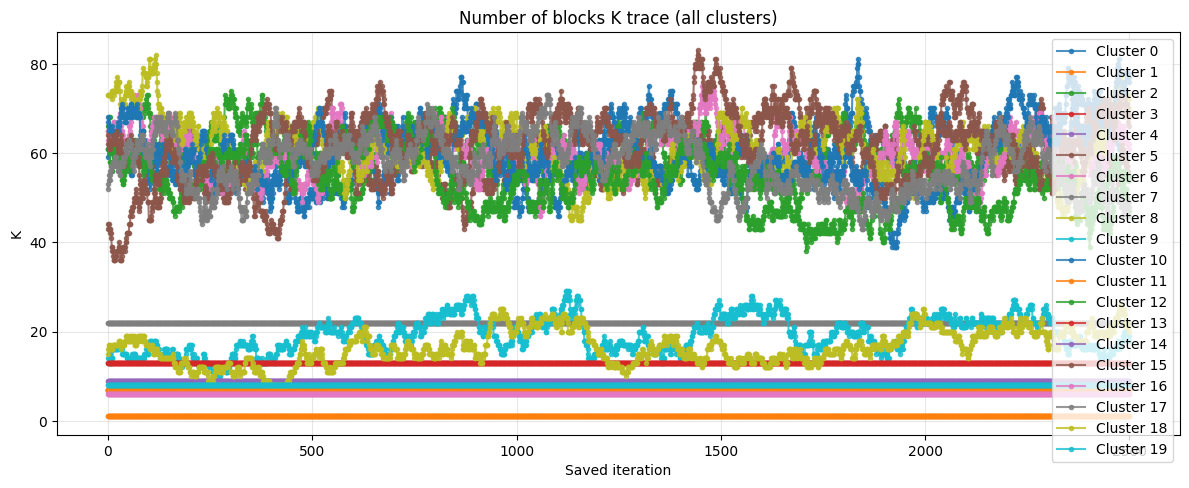

In [44]:
model.plot_trace_K()

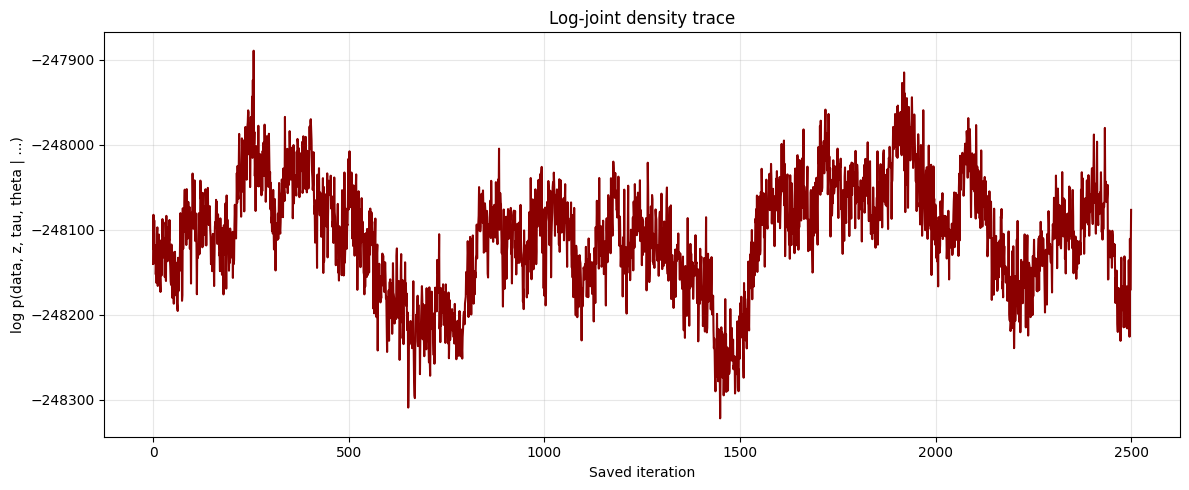

In [46]:
model.plot_trace_logp()

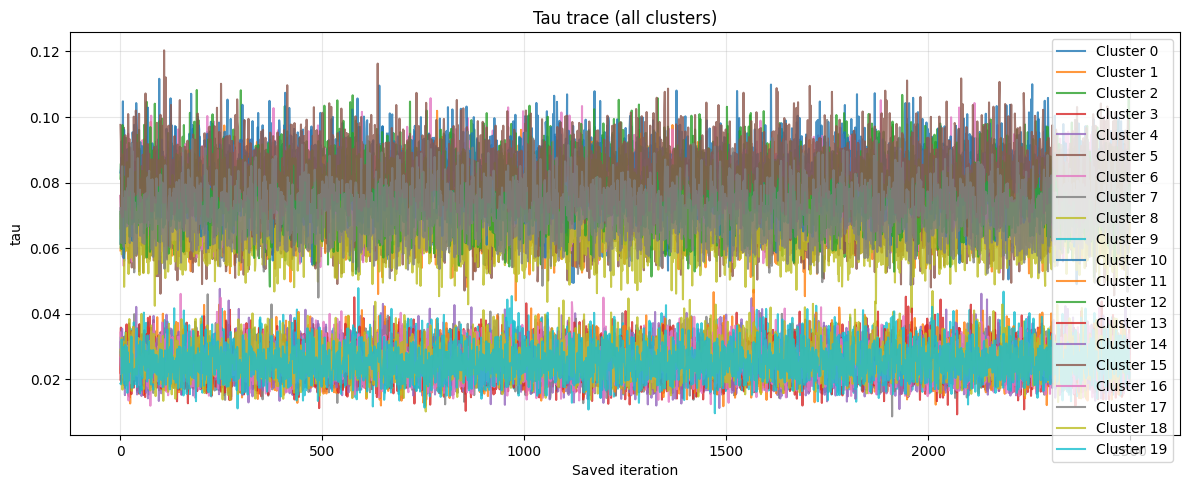

In [47]:
model.plot_trace_tau()

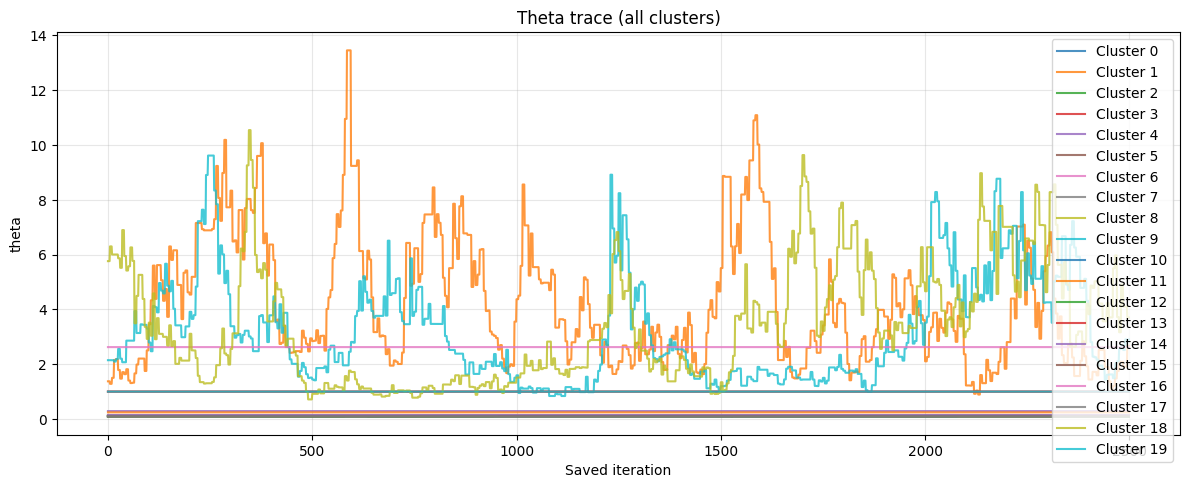

In [48]:
model.plot_trace_theta()

## Partial Rankings: Modified Likelihood and Impact on the Actual Computations

### Representing partial (top-$m$) rankings

Represent assessor $i$'s partial ranking by placing the $m_i$ observed items at positions $1\ldots m_i$ and the $n - m_i$ unranked items at positions $m_i{+}1\ldots n$ in **canonical order** (e.g. numerical order of item indices). This is how `compute_U_all` via `np.argsort` naturally behaves.

---

### Modified log-likelihood

Marginalising over the $(n-m_i)!$ completions gives:

$$\log P(\pi^{(m_i)}_i \mid \rho_c, \theta_c) = -\theta_c\bigl(U_A^{(i,c)} + p\,T_m(\rho_c)\bigr) + \log C(\rho_c, A^c_i, \theta_c) - \log Z^*(\rho_c, \theta_c)$$

where $U_A^{(i,c)}$ counts only cross-block inversions among the **observed** items of assessor $i$, and the **completion factor** is a q-multinomial over the unranked items per block:

$$\log C = \log[n{-}m_i]_q! + \sum_k \log(m_{k,i}!) - \sum_k \log[m_{k,i}]_q!, \quad m_{k,i} = |B_k \cap A^c_i|$$

The normaliser $Z^*$ and the $-\theta p T_m$ term are **unchanged**.

---

### Impact on `_update_z` (the BLAS matmul)

`_update_z` computes logweights via a single matmul:

```python
D = U_all @ M.T + offsets       # (N, C)
logweights = log_tau - theta * (D + p * Tm) - logZ
```

`D[i,c]` counts cross-block inversions over **all** $\binom{n}{2}$ pairs. With the canonical fill, four pair types contribute to each row of `U_all`:

| Pair type | `U_all[i, pair(a,b)]` | Correct? |
|---|---|---|
| Both $a,b \in A_i$ (both observed) | direct 0/1 from ranking | ✓ |
| $a \in A_i$, $b \notin A_i$ | 0 — observed always beats unranked | ✓ |
| $a \notin A_i$, $b \in A_i$ | 1 — unranked always after observed | ✓ |
| Both $a,b \notin A_i$ | 0 or 1 from canonical fill order | ✗ |

The first three cases are handled correctly for free by the fill convention: all ranked items appear at positions $\leq m_i < m_i{+}1 \leq$ all unranked items, so `argsort` gives the right relative ordering. The only error is the **unobserved-pair contribution** $U_{A^c}^{(i)}(\text{fill}, \rho_c)$ — cross-block inversions among the canonically ordered unranked items.

To obtain exact partial-ranking logweights, two additive corrections are needed **after** the matmul:

$$\text{correction}[i,c] = \underbrace{\theta_c \cdot U_{A^c}^{(i)}(\text{fill}, \rho_c)}_{\text{remove wrong unobserved-pair contribution}} + \underbrace{\log C(\rho_c, A^c_i, \theta_c)}_{\text{add completion factor}}$$

Both terms depend on $A^c_i$ and $\rho_c$, making this a dense $N \times C$ correction matrix computed outside the matmul. The matmul itself is **unchanged**; the additional cost is computing this matrix, which is $O(N \cdot n \cdot C)$ in the worst case. When all assessors have full rankings ($A^c_i = \emptyset$), both terms vanish identically.

---

### Impact on `fast_gibbs_reassign_one_item` (block-structure update)

The Gibbs move precomputes the cluster sufficient statistic:

```python
H = U_all[cluster_mask].sum(axis=0)   # shape (n_pairs,)
h_vals[x] = #{cluster assessors: l ranked after x}
```

All candidates for $l$'s block placement are then evaluated in $O(n + K)$ using prefix/suffix sums over $H_{\text{gt/lt}}$ grouped by block. This works because $H$ is **independent of the proposal**.

For partial rankings, $h_\text{vals}[x]$ decomposes over four assessor types:

| Assessor type | Contribution to $h_\text{vals}[x]$ | From canonical fill? |
|---|---|---|
| $l \in A_i$, $x \in A_i$ | directly 0/1 from ranking | ✓ already correct |
| $l \notin A_i$, $x \in A_i$ | always 1 ($l$ unranked, after $x$) | ✓ fill gives 1 |
| $l \in A_i$, $x \notin A_i$ | always 0 ($l$ observed, before $x$) | ✓ fill gives 0 |
| $l \notin A_i$, $x \notin A_i$ | fixed 0/1 from canonical fill | ✗ **problem** |

The last case is the key issue. The correct contribution for two **jointly unobserved** items is:

$$E\bigl[1\{l \text{ after } x\} \mid B_l, B_x, \theta\bigr] \approx \begin{cases} 1 & B_l > B_x,\ \theta \to \infty \\ 0 & B_l < B_x,\ \theta \to \infty \\ 0.5 & B_l = B_x \text{ or } \theta \to 0 \end{cases}$$

This expectation depends on the **proposed block position of $l$**, so $H$ is no longer a proposal-independent sufficient statistic. The O(n + K) pass over all candidates breaks — the doubly-unobserved contribution changes with every proposal.

**Practical severity**: the problematic assessors are those where **both** $l$ and $x$ are unranked. In expectation that fraction is $((n-m_i)/n)^2$, which is negligible when most items are observed. For sparse rankings (small $m_i$) the error can be material.

**Tractable correction**: replace the doubly-unobserved contribution with $1/2$ per pair per assessor (exact at $\theta=0$, conservative for large $\theta$). Concretely, for each item $x$ let $N_{ll}[x] = \#\{i \in \text{cluster}: l \notin A_i, x \notin A_i\}$ and $h_\text{fill}[x]$ be the canonical fill contribution for those assessors. Set:

$$h_\text{vals\_corrected}[x] = H[x] - h_\text{fill}[x] + \tfrac{1}{2} N_{ll}[x]$$

This correction is **proposal-independent** — it only depends on missingness and canonical fill, both of which are fixed. The prefix/suffix structure and $O(n + K)$ evaluation of candidates is therefore **preserved**.
